In [1]:
import json
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

### JSON reading and binarization of the labels (none, implicit)

In [ ]:

path_json = "/Users/deniseatzori/Library/Mobile Documents/com~apple~CloudDocs/ENC-PSL/Cours/Python avancé/Data/enthymemes_2/merged_annotations_v2.json"

with open(path_json, "r", encoding="utf-8") as f:
    data = json.load(f)

tweets = []
labels = []

for entry in data:
    testo = entry["tweet_text"]
    label_orig = entry["majority_label"]
    
    # Binarizzazione: "none" -> "none", qualsiasi altra cosa -> "implicit"
    label_bin = "none" if label_orig == "none" else "implicit"
    
    tweets.append(testo)
    labels.append(label_bin)

print(f"Totale esempi: {len(tweets)}")
print(f"Distribuzione label: none={labels.count('none')}, implicit={labels.count('implicit')}")

Totale esempi: 1333
Distribuzione label: none=882, implicit=451


### Features estraction with n-grams (TF-IDF)

In [ ]:
# Estrazione di uni- e bi-grammi a livello di parola
# ngram_range=(1,1) per soli unigrammi, (2,2) per soli bigrammi, ecc.
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,           # ignora n-grammi che appaiono in meno di 2 documenti
    sublinear_tf=True,  # scala logaritmica per i TF
    strip_accents="unicode",
    analyzer="word"
)

X = vectorizer.fit_transform(tweets)
y = np.array(labels)
lista_features = vectorizer.get_feature_names_out()

print(f"Numero features (n-grammi): {X.shape[1]}")
print(f"Numero esempi: {X.shape[0]}")

Numero features (n-grammi): 6542
Numero esempi: 1333


### Split train / test / validation

In [4]:
from sklearn.model_selection import train_test_split

# Prima divisione: train vs (test + validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Seconda divisione: test vs validation (50/50 della parte temporanea)
X_test, X_validation, y_test, y_validation = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape[0]} esempi")
print(f"Test:  {X_test.shape[0]} esempi")
print(f"Validation: {X_validation.shape[0]} esempi")

Train: 933 esempi
Test:  200 esempi
Validation: 200 esempi


### 5 fold Cross-validation on training set

In [8]:
svc = LinearSVC(C=1.0, max_iter=5000, random_state=42, class_weight='balanced')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(svc, X_train, y_train, cv=cv, scoring="f1_macro")

print(f"Cross-validation F1 macro (5-fold): {cv_scores}")
print(f"Media: {cv_scores.mean():.4f}  |  Std: {cv_scores.std():.4f}")

Cross-validation F1 macro (5-fold): [0.55014006 0.57935202 0.61619439 0.55955798 0.65233645]
Media: 0.5915  |  Std: 0.0379


In [9]:
# Addestramento sul training set completo
svc.fit(X_train, y_train)

# Valutazione sul validation set
val_predictions = svc.predict(X_validation)
print("=== Validation set ===")
print(classification_report(y_validation, val_predictions, zero_division=0))

# Valutazione sul test set
test_predictions = svc.predict(X_test)
print("=== Test set ===")
print(classification_report(y_test, test_predictions, zero_division=0))

=== Validation set ===
              precision    recall  f1-score   support

    implicit       0.41      0.32      0.36        68
        none       0.68      0.76      0.72       132

    accuracy                           0.61       200
   macro avg       0.55      0.54      0.54       200
weighted avg       0.59      0.61      0.60       200

=== Test set ===
              precision    recall  f1-score   support

    implicit       0.43      0.36      0.39        67
        none       0.70      0.76      0.73       133

    accuracy                           0.62       200
   macro avg       0.56      0.56      0.56       200
weighted avg       0.61      0.62      0.62       200



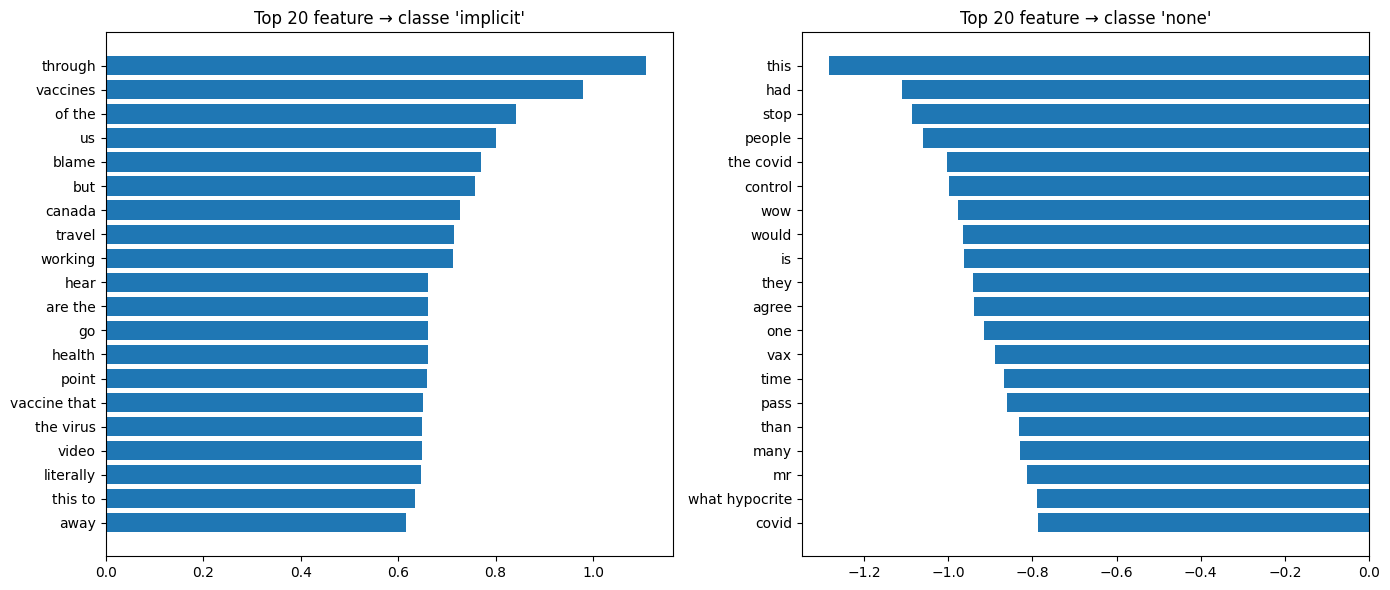

In [7]:
# Con classificazione binaria, coef_ ha shape (1, n_features)
coefs = svc.coef_[0]  # vettore 1D

# Top 20 feature per la classe "implicit" (coefficienti più alti)
feature_importances = dict(zip(lista_features, coefs))
sorted_pos = dict(sorted(feature_importances.items(), key=lambda x: x[1], reverse=True))
sorted_neg = dict(sorted(feature_importances.items(), key=lambda x: x[1]))

num_to_plot = 20

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Feature più importanti per "implicit"
ax1.barh(range(num_to_plot), list(sorted_pos.values())[:num_to_plot], align="center")
ax1.set_yticks(range(num_to_plot))
ax1.set_yticklabels(list(sorted_pos.keys())[:num_to_plot])
ax1.set_title("Top 20 feature → classe 'implicit'")
ax1.invert_yaxis()

# Feature più importanti per "none"
ax2.barh(range(num_to_plot), list(sorted_neg.values())[:num_to_plot], align="center")
ax2.set_yticks(range(num_to_plot))
ax2.set_yticklabels(list(sorted_neg.keys())[:num_to_plot])
ax2.set_title("Top 20 feature → classe 'none'")
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

### Optical C with cross-validation

In [10]:
from sklearn.model_selection import GridSearchCV

param_grid = {'C': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]}

grid_search = GridSearchCV(
    LinearSVC(max_iter=5000, random_state=42, class_weight='balanced'),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',   # o 'f1' se vuoi ottimizzare solo sugli implicit
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print(f"Miglior C: {grid_search.best_params_['C']}")
print(f"Miglior F1 macro in CV: {grid_search.best_score_:.4f}")

svc = grid_search.best_estimator_

Miglior C: 0.01
Miglior F1 macro in CV: 0.6137


### Decision threshold with CalibratedClassifierCV

In [11]:
from sklearn.calibration import CalibratedClassifierCV

svc_base = LinearSVC(C=1.0, max_iter=5000, random_state=42, class_weight='balanced')
calibrated_svc = CalibratedClassifierCV(svc_base, cv=5)
calibrated_svc.fit(X_train, y_train)

# Probabilità predette
proba = calibrated_svc.predict_proba(X_test)
# classes_: ['implicit', 'none'] -> controlla l'ordine con calibrated_svc.classes_
idx_implicit = list(calibrated_svc.classes_).index('implicit')

# Abbassa la soglia da 0.5 a 0.35 per aumentare il recall sugli implicit
soglia = 0.35
test_predictions_custom = np.where(proba[:, idx_implicit] >= soglia, 'implicit', 'none')

print(classification_report(y_test, test_predictions_custom, zero_division=0))

              precision    recall  f1-score   support

    implicit       0.45      0.57      0.50        67
        none       0.75      0.65      0.70       133

    accuracy                           0.62       200
   macro avg       0.60      0.61      0.60       200
weighted avg       0.65      0.62      0.63       200



### TfidfVectorizer optimization

In [13]:
# Recupera i testi raw corrispondenti agli split già creati
# (assumendo che tu abbia usato train_test_split con gli indici)

# Se hai usato train_test_split su X e y, rifai lo split anche sui testi:
tweets_array = np.array(tweets)  # converti la lista in array per indicizzare

tweets_train, tweets_temp, y_train_raw, y_temp = train_test_split(
    tweets_array, y, test_size=0.3, random_state=42, stratify=y
)
tweets_test, tweets_validation, y_test_raw, y_validation_raw = train_test_split(
    tweets_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Verifica che i label corrispondano a quelli già usati
assert np.array_equal(y_train_raw, y_train), "Mismatch nei label train!"
print(f"tweets_train: {len(tweets_train)}, tweets_test: {len(tweets_test)}, tweets_validation: {len(tweets_validation)}")

tweets_train: 933, tweets_test: 200, tweets_validation: 200


In [14]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(sublinear_tf=True, strip_accents='unicode')),
    ('clf', LinearSVC(max_iter=5000, random_state=42, class_weight='balanced'))
])

param_grid = {
    'tfidf__ngram_range': [(1,1), (1,2), (1,3), (2,2)],
    'tfidf__min_df':      [1, 2, 3],
    'tfidf__max_features':[None, 5000, 10000, 20000],
    'tfidf__analyzer':    ['word', 'char_wb'],  # char_wb spesso buono su tweet
    'clf__C':             [0.1, 0.5, 1.0, 5.0],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
grid.fit(tweets_train, y_train)  # nota: passa i testi raw, non X_train

print(f"Miglior configurazione: {grid.best_params_}")
print(f"Miglior F1 macro CV:    {grid.best_score_:.4f}")

best_pipeline = grid.best_estimator_

Fitting 5 folds for each of 384 candidates, totalling 1920 fits
Miglior configurazione: {'clf__C': 0.5, 'tfidf__analyzer': 'word', 'tfidf__max_features': None, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 3)}
Miglior F1 macro CV:    0.6143


### Refine the threshold using the precision-recall curve

Soglia ottimale (su validation): 0.2429
F1 implicit atteso: 0.5405


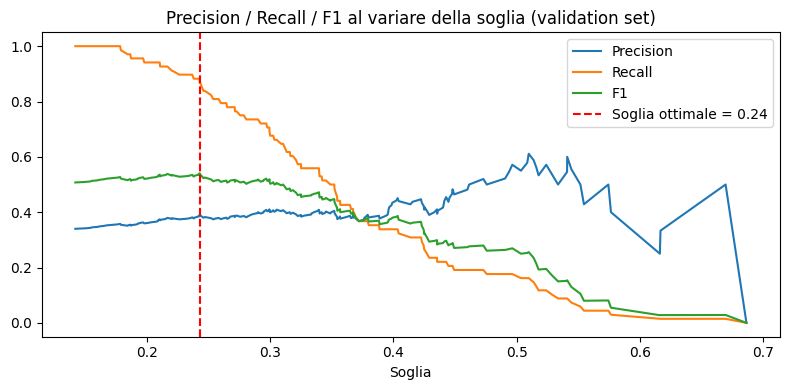

              precision    recall  f1-score   support

    implicit       0.40      0.97      0.57        67
        none       0.95      0.28      0.43       133

    accuracy                           0.51       200
   macro avg       0.68      0.62      0.50       200
weighted avg       0.77      0.51      0.48       200



In [15]:
from sklearn.metrics import precision_recall_curve, f1_score

# Usa il modello calibrato sulla validation
proba_val = calibrated_svc.predict_proba(X_validation)
idx_implicit = list(calibrated_svc.classes_).index('implicit')
scores_val = proba_val[:, idx_implicit]

# Calcola precision, recall e soglie
precisions, recalls, soglie = precision_recall_curve(y_validation, scores_val, pos_label='implicit')

# Trova la soglia che massimizza F1 sugli implicit
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_soglia = soglie[best_idx]

print(f"Soglia ottimale (su validation): {best_soglia:.4f}")
print(f"F1 implicit atteso: {f1_scores[best_idx]:.4f}")

# Visualizzazione
plt.figure(figsize=(8, 4))
plt.plot(soglie, precisions[:-1], label='Precision')
plt.plot(soglie, recalls[:-1], label='Recall')
plt.plot(soglie, f1_scores[:-1], label='F1')
plt.axvline(best_soglia, color='red', linestyle='--', label=f'Soglia ottimale = {best_soglia:.2f}')
plt.xlabel('Soglia')
plt.legend()
plt.title('Precision / Recall / F1 al variare della soglia (validation set)')
plt.tight_layout()
plt.show()

# Applica la soglia ottimale al test set
proba_test = calibrated_svc.predict_proba(X_test)
test_predictions_opt = np.where(
    proba_test[:, idx_implicit] >= best_soglia, 'implicit', 'none'
)
print(classification_report(y_test, test_predictions_opt, zero_division=0))